<a href="https://colab.research.google.com/github/saatvikpvs/HealthGuard-analytics/blob/main/HealthGuard_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

# 2. Load Dataset

In [5]:
# Load the dataset
df = pd.read_csv("patient.csv")

# Display first 5 rows
df.head()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


# 3. Basic Information About Dataset

In [6]:
# Number of rows and columns
print("Shape of dataset:", df.shape)

# Information about columns
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of dataset: (4212, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    object 
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   object 
 4   region            305 non-null    object 
 5   group             76 non-null     object 
 6   infection_reason  130 non-null    object 
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   object 
 11  released_date     28 non-null     object 
 12  deceased_date     13 non-null     object 
 13  state             4212 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 460.8+ KB

Missing Values:
id                     0
sex   

# 4. Calculate Age

In [7]:
# Calculate age from birth year
df['age'] = 2020 - df['birth_year']

df[['birth_year', 'age']].head()

,birth_year,age
0,1984.0,36.0
1,1964.0,56.0
2,1966.0,54.0
3,1964.0,56.0
4,1987.0,33.0


# 5. Convert Date Columns

In [8]:
date_columns = ['confirmed_date', 'released_date', 'deceased_date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 6. Calculate Recovery Duration

In [9]:
# Calculate recovery time in days
df['recovery_days'] = (
    df['released_date'] - df['confirmed_date']
).dt.days

df[['confirmed_date',
    'released_date',
    'recovery_days']].head()

,confirmed_date,released_date,recovery_days
0,2020-01-20,2020-02-06,17.0
1,2020-01-24,2020-02-05,12.0
2,2020-01-26,2020-02-12,17.0
3,2020-01-27,2020-02-09,13.0
4,2020-01-30,NaT,NaN


# 7. Create Age Groups

In [10]:
bins = [0, 20, 40, 60, 80, 120]
labels = ['0-20', '21-40', '41-60', '61-80', '80+']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

# **Gender Distribution**

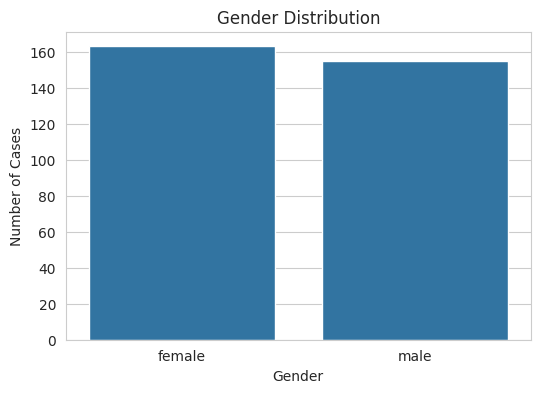

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='sex')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Cases")

plt.show()

female patients are more affected more than male patients

# **Age Distribution**

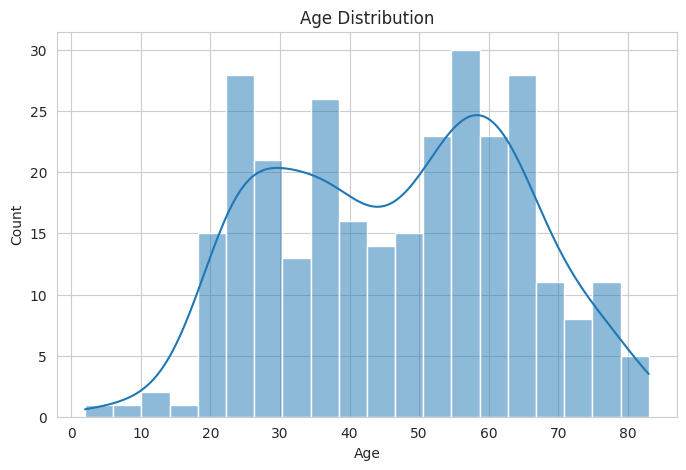

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'].dropna(),
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

# **Age Group Distribution**

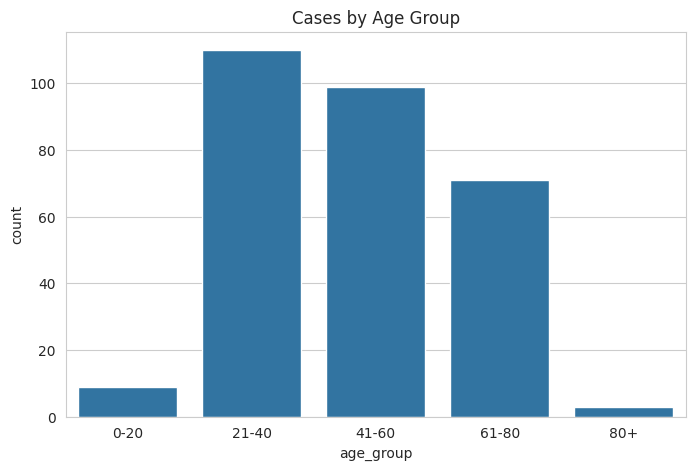

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='age_group'
)

plt.title("Cases by Age Group")

plt.show()

Most cases belongs to the age group 21-40

# **Country Distribution**

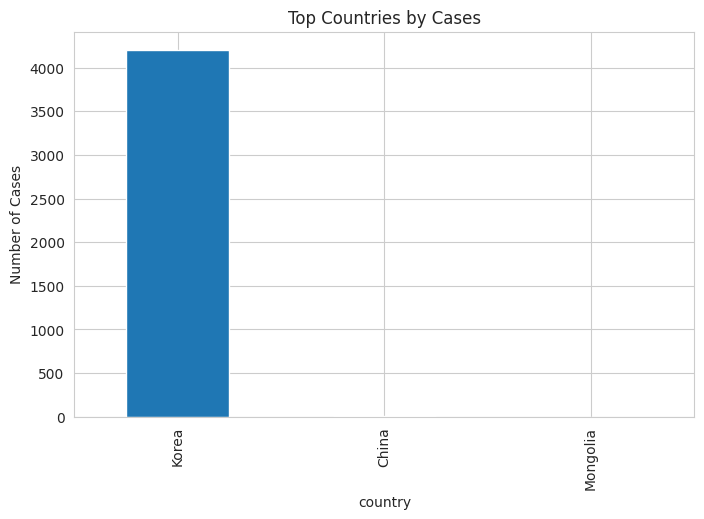

In [14]:
plt.figure(figsize=(8,5))

df['country'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Countries by Cases")
plt.ylabel("Number of Cases")

plt.show()

# **Region Distribution**

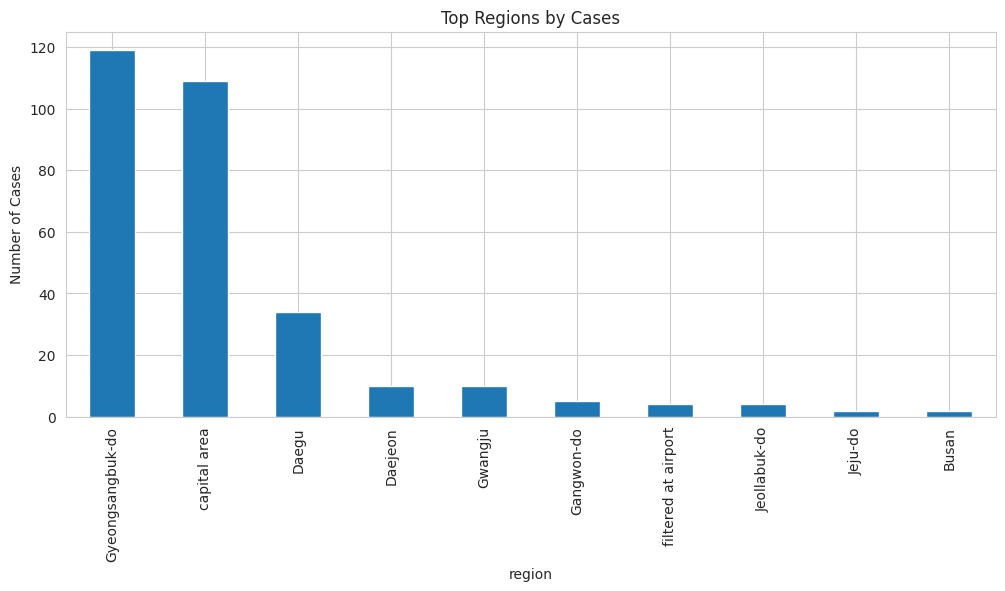

In [18]:
plt.figure(figsize=(12,5))

df['region'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Regions by Cases")
plt.ylabel("Number of Cases")

plt.show()

# ***How are infections spreading?***



# **Infection Reason**

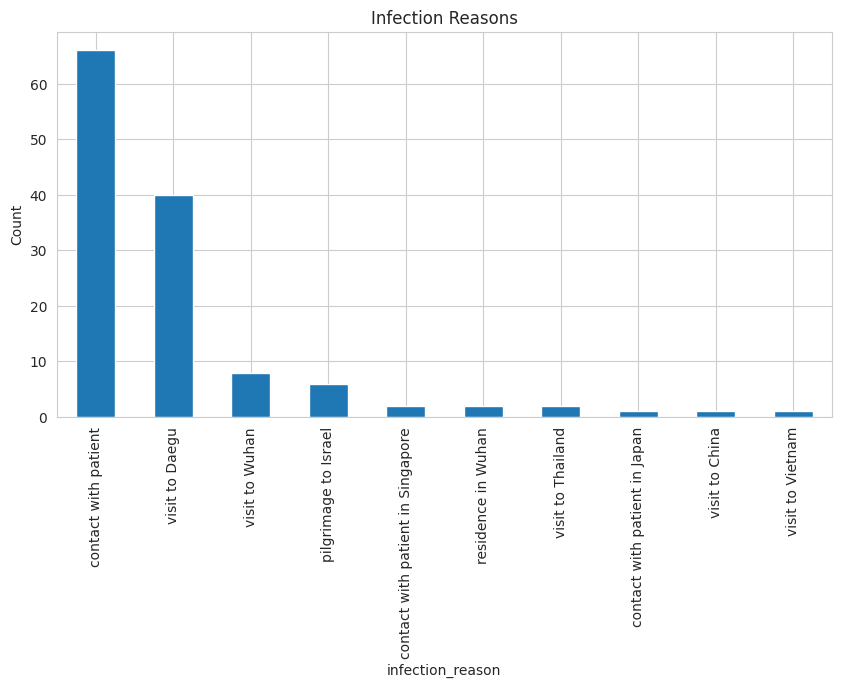

In [19]:
plt.figure(figsize=(10,5))

df['infection_reason'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Infection Reasons")
plt.ylabel("Count")

plt.show()

#**Infection Order**

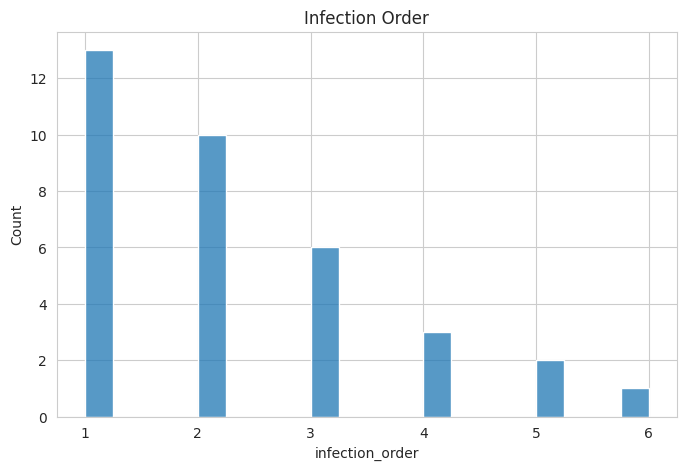

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['infection_order'].dropna(),
    bins=20
)

plt.title("Infection Order")

plt.show()

# **Contact Exposure Levels**

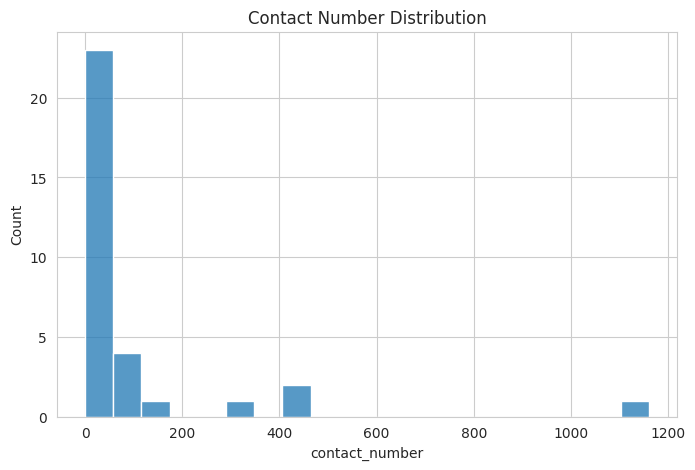

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['contact_number'].dropna(),
    bins=20
)

plt.title("Contact Number Distribution")

plt.show()

# ***Recovery Trends***

In [22]:
recovered = df[
    df['state'] == 'released'
]

print(
    "Average Recovery Time:",
    round(
        recovered['recovery_days'].mean(),
        2
    ),
    "days"
)

Average Recovery Time: 15.11 days


# **Recovery Duration Distribution**

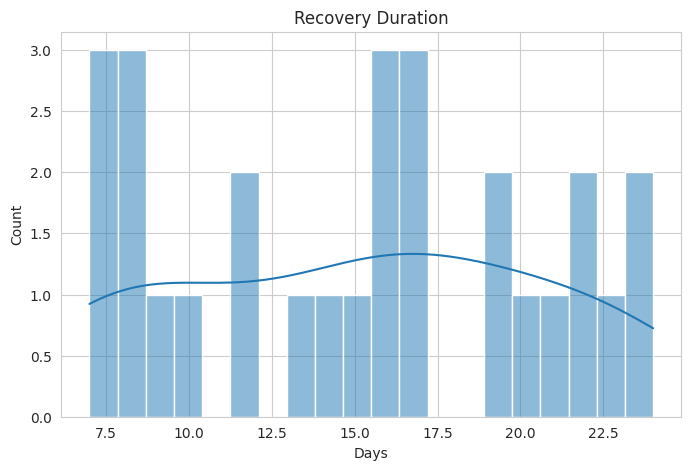

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    recovered['recovery_days'].dropna(),
    bins=20,
    kde=True
)

plt.title("Recovery Duration")

plt.xlabel("Days")

plt.show()

# **Recovery by Age Group**

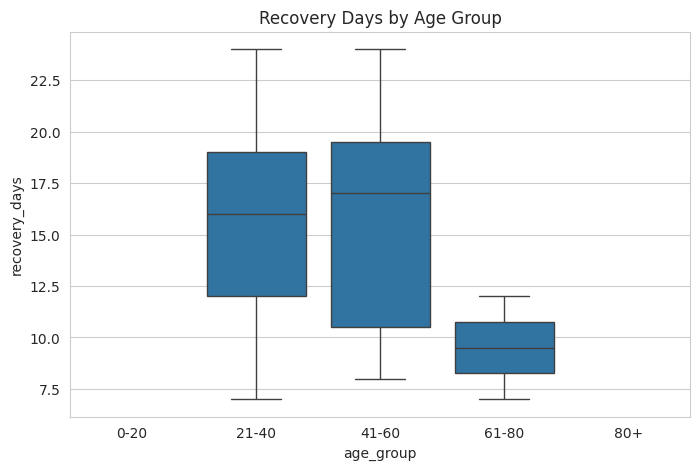

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='age_group',
    y='recovery_days'
)

plt.title("Recovery Days by Age Group")

plt.show()

# **Recovery by Gender**

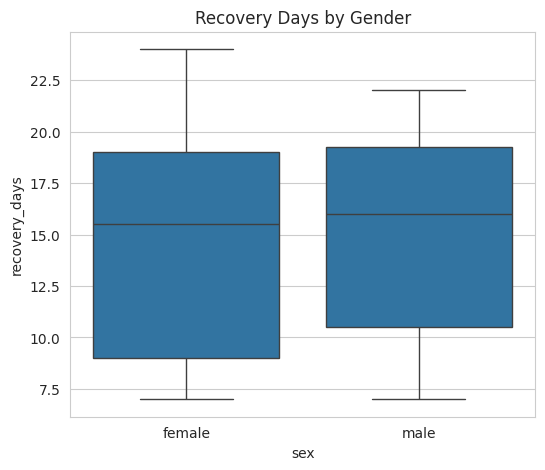

In [25]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x='sex',
    y='recovery_days'
)

plt.title("Recovery Days by Gender")

plt.show()

# **Patient Outcomes**

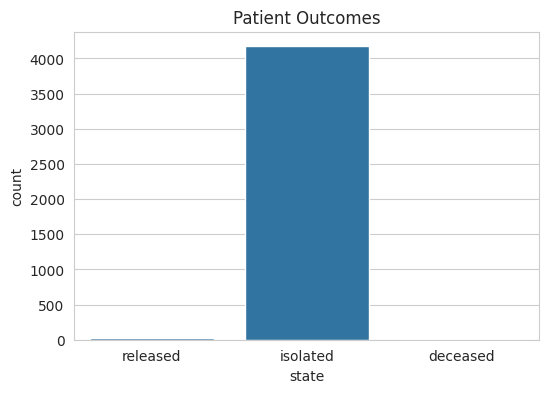

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='state'
)

plt.title("Patient Outcomes")

plt.show()

# ***Most Impacted Regions***

# **Confirmed Cases**

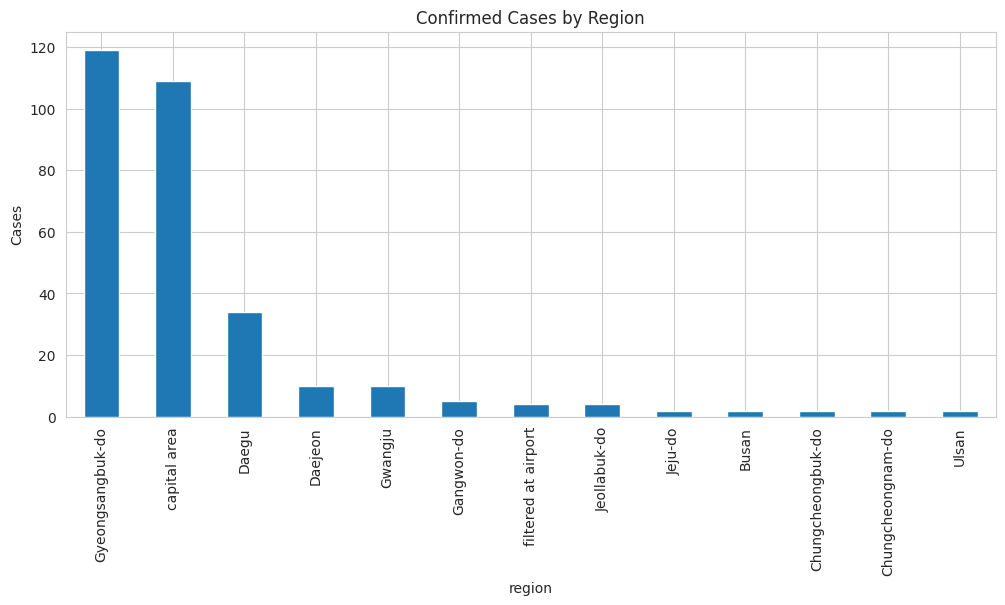

In [27]:
plt.figure(figsize=(12,5))

df['region'].value_counts().head(15).plot(
    kind='bar'
)

plt.title("Confirmed Cases by Region")

plt.ylabel("Cases")

plt.show()

# **Released Cases**

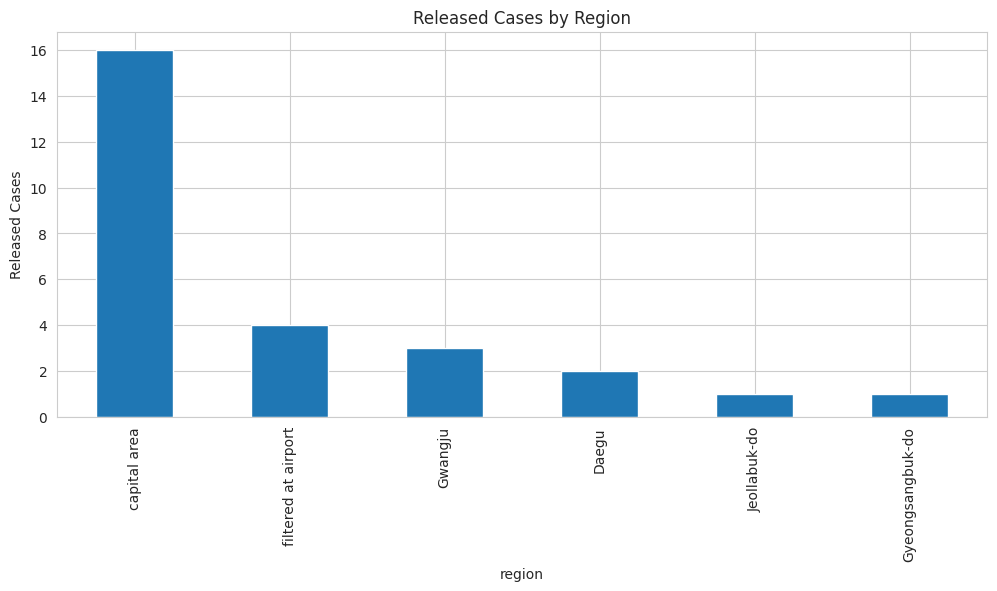

In [28]:
released_region = (
    df[
        df['state'] == 'released'
    ]['region']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,5))

released_region.plot(
    kind='bar'
)

plt.title("Released Cases by Region")

plt.ylabel("Released Cases")

plt.show()

# ***Correlation Analysis***

<Axes: >

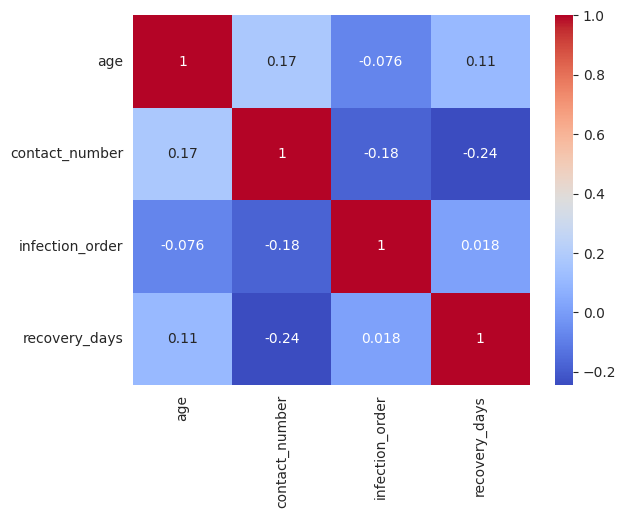

In [35]:
model_df = df[
    [
        'age',
        'contact_number',
        'infection_order',
        'recovery_days'
    ]
].dropna()

sns.heatmap(
    model_df.corr(),
    annot=True,
    cmap='coolwarm'
)

**Why we used it:**

Correlation analysis was used to check whether factors such as age, contact number, and infection order affect recovery time.

**Findings:**

Age had a weak positive relationship with recovery days (0.11).
Contact number had a weak negative relationship (-0.24).
Infection order had almost no relationship with recovery days (0.018).

# ***Linear Regression***

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features
X = model_df[
    ['age',
     'contact_number',
     'infection_order']
]

# Target
y = model_df['recovery_days']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict recovery days
predictions = model.predict(X_test)

# **Model Evaluation**

In [33]:
r2 = r2_score(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("R2 Score:", round(r2, 3))
print("RMSE:", round(rmse, 3))

R2 Score: -0.658
RMSE: 3.397


# **Feature Importance**

In [34]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

           Feature  Coefficient
0              age     0.078771
1   contact_number    -0.009186
2  infection_order     0.021251


**Why we used it:**

Linear Regression was used to predict recovery duration and understand the effect of different patient factors on recovery.

**Results:**

R² Score: -0.658
RMSE: 3.397

**Conclusion:**

The model was not able to predict recovery time accurately. This suggests that recovery may depend on other factors that are not present in the dataset.